# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** Muyassaroh
- **Email:** muyassaroh9691@gmail.com
- **ID Dicoding:** CDCC180D6X2507

## Menentukan Pertanyaan Bisnis
- **1.** Kategori produk apa yang menghasilkan total revenue (harga + ongkos kirim) tertinggi, dan bagaimana tren revenue bulanannya selama periode 2017–2018?
  - **Specific:** Fokus pada kategori produk dan metric revenue (price + freight).
  - **Measurable:** Revenue dihitung dalam satuan R$ (Brazilian Real).
  - **Action-Oriented:** Hasilnya bisa digunakan untuk menentukan prioritas stok dan promosi.
  - **Relevant:** Revenue adalah KPI utama bisnis e-commerce.
  - **Time-bound:** Dibatasi pada periode 2017–2018.

- **2.** Apakah durasi pengiriman (jumlah hari dari pembelian hingga diterima) berpengaruh terhadap skor review pelanggan pada pesanan berstatus *delivered* sepanjang 2016–2018?
  - **Specific:** Fokus pada hubungan antara delivery_days dan review_score.
  - **Measurable:** Diukur dari selisih hari antara order_purchase_timestamp dan order_delivered_customer_date.
  - **Action-Oriented:** Hasilnya dapat digunakan untuk menetapkan SLA pengiriman.
  - **Relevant:** Kepuasan pelanggan (review) adalah indikator kualitas layanan e-commerce.
  - **Time-bound:** Data mencakup seluruh periode dataset 2016–2018.

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** xxx
- **Pertanyaan 2:** xxx
- ...

## Import Semua Packages/Library yang Digunakan

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('Set2')

print('✅ Libraries loaded successfully!')

✅ Libraries loaded successfully!


## Data Wrangling

### Gathering Data

Pada tahap ini, kita memuat semua dataset dari E-Commerce Public Dataset (Olist).
Dataset terdiri dari beberapa tabel relasional yang dihubungkan via `order_id`, `product_id`, `customer_id`, dan `seller_id`.

In [30]:
from google.colab import files
import zipfile
import os

uploaded = files.upload()

zip_filename = list(uploaded.keys())[0]
with zipfile.ZipFile(zip_filename, 'r') as z:
    z.extractall('.')

for root, dirs, filenames in os.walk('.'):
    for f in filenames:
        if f.endswith('.csv'):
            print(os.path.join(root, f))

Saving E-commerce-public-dataset.zip to E-commerce-public-dataset (2).zip
./E-Commerce Public Dataset/sellers_dataset.csv
./E-Commerce Public Dataset/order_items_dataset.csv
./E-Commerce Public Dataset/order_reviews_dataset.csv
./E-Commerce Public Dataset/products_dataset.csv
./E-Commerce Public Dataset/geolocation_dataset.csv
./E-Commerce Public Dataset/order_payments_dataset.csv
./E-Commerce Public Dataset/orders_dataset.csv
./E-Commerce Public Dataset/customers_dataset.csv
./E-Commerce Public Dataset/product_category_name_translation.csv
./sample_data/california_housing_test.csv
./sample_data/mnist_train_small.csv
./sample_data/mnist_test.csv
./sample_data/california_housing_train.csv


#### Load df ...

In [31]:
BASE = './E-Commerce Public Dataset/'

orders_df         = pd.read_csv(BASE + 'orders_dataset.csv')
order_items_df    = pd.read_csv(BASE + 'order_items_dataset.csv')
order_payments_df = pd.read_csv(BASE + 'order_payments_dataset.csv')
order_reviews_df  = pd.read_csv(BASE + 'order_reviews_dataset.csv')
customers_df      = pd.read_csv(BASE + 'customers_dataset.csv')
products_df       = pd.read_csv(BASE + 'products_dataset.csv')
sellers_df        = pd.read_csv(BASE + 'sellers_dataset.csv')
translation_df    = pd.read_csv(BASE + 'product_category_name_translation.csv')

print('Shape masing-masing dataset:')
datasets = {
    'orders': orders_df,
    'order_items': order_items_df,
    'order_payments': order_payments_df,
    'order_reviews': order_reviews_df,
    'customers': customers_df,
    'products': products_df,
    'sellers': sellers_df,
    'translation': translation_df,
}
for name, df in datasets.items():
    print(f'  {name}: {df.shape}')

Shape masing-masing dataset:
  orders: (99441, 8)
  order_items: (112650, 7)
  order_payments: (103886, 5)
  order_reviews: (99224, 7)
  customers: (99441, 5)
  products: (32951, 9)
  sellers: (3095, 4)
  translation: (71, 2)


**Insight:**
- Dataset terdiri dari 8 tabel relasional yang saling terhubung.
- `orders_dataset` merupakan tabel utama dengan ~99K baris.
- Kolom timestamp pada `orders_df` masih bertipe `object`, perlu dikonversi ke `datetime`.
- Terdapat beberapa kolom dengan missing value yang akan ditangani di tahap Cleaning Data.

### Assessing Data

Pada tahap ini kita menilai kualitas data dengan mengidentifikasi:
1. Missing values
2. Tipe data yang tidak sesuai
3. Duplikasi data

#### Identifying Missing Value

In [32]:
print('=== Missing Values: orders_df ===')
print(orders_df.isnull().sum())
print()
print('=== Missing Values: products_df ===')
print(products_df.isnull().sum())
print()
print('=== Missing Values: order_reviews_df ===')
print(order_reviews_df.isnull().sum())

=== Missing Values: orders_df ===
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

=== Missing Values: products_df ===
product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

=== Missing Values: order_reviews_df ===
review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64


**Steps to Take:**
- `orders_df`: Kolom `order_delivered_customer_date` memiliki 2.965 missing value → akan difilter karena analisis hanya pada pesanan *delivered*.
- `products_df`: Kolom `product_category_name` memiliki 610 missing value → akan diisi `'unknown'` setelah merge dengan tabel terjemahan.
- `order_reviews_df`: Kolom komentar banyak null → wajar karena pelanggan tidak wajib mengisi komentar, tidak perlu ditangani.

#### Identifying Incorrect Data Type

In [33]:
print('=== Tipe Data: orders_df ===')
print(orders_df.dtypes)
print()
print('Kolom timestamp berikut masih bertipe object, seharusnya datetime:')
print([c for c in orders_df.columns if 'date' in c or 'timestamp' in c])

=== Tipe Data: orders_df ===
order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object

Kolom timestamp berikut masih bertipe object, seharusnya datetime:
['order_purchase_timestamp', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']


**Steps to Take:**
- Semua kolom timestamp pada `orders_df` harus dikonversi ke tipe `datetime` menggunakan `pd.to_datetime()`.

#### Identifying Duplicate Data

In [34]:
print('Jumlah baris duplikat per dataset:')
for name, df in datasets.items():
    print(f'  {name}: {df.duplicated().sum()} duplikat')

Jumlah baris duplikat per dataset:
  orders: 0 duplikat
  order_items: 0 duplikat
  order_payments: 0 duplikat
  order_reviews: 0 duplikat
  customers: 0 duplikat
  products: 0 duplikat
  sellers: 0 duplikat
  translation: 0 duplikat


**Insight:**
- Ditemukan 2 permasalahan utama: **missing value** (pada kolom tanggal pengiriman dan kategori produk) dan **tipe data tidak sesuai** (kolom timestamp masih object).
- Tidak ditemukan data duplikat pada seluruh dataset.

### Cleaning Data

Berdasarkan temuan di Assessing Data, kita melakukan pembersihan:
1. Konversi tipe data timestamp
2. Filter pesanan delivered & hapus baris dengan tanggal pengiriman null
3. Merge dan isi missing value kategori produk

#### Fixing All problems

In [35]:
# 1. Konversi tipe data timestamp
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
for col in date_cols:
    orders_df[col] = pd.to_datetime(orders_df[col])

# 2. Filter pesanan delivered & hapus missing tanggal pengiriman
delivered_df = orders_df[orders_df['order_status'] == 'delivered'].copy()
delivered_df = delivered_df.dropna(subset=['order_delivered_customer_date'])

# 3. Feature engineering
delivered_df['delivery_days'] = (
    delivered_df['order_delivered_customer_date'] - delivered_df['order_purchase_timestamp']
).dt.days
delivered_df['month'] = delivered_df['order_purchase_timestamp'].dt.to_period('M').astype(str)
delivered_df['year']  = delivered_df['order_purchase_timestamp'].dt.year

# 4. Merge items + products + terjemahan & isi missing category
items_full = order_items_df.merge(
    products_df[['product_id', 'product_category_name']], on='product_id', how='left'
)
items_full = items_full.merge(translation_df, on='product_category_name', how='left')
items_full['product_category_name_english'] = (
    items_full['product_category_name_english'].fillna('unknown')
)
items_full['revenue'] = items_full['price'] + items_full['freight_value']

# 5. Dataset final untuk analisis
rev_df = delivered_df.merge(
    items_full[['order_id', 'product_category_name_english', 'price', 'freight_value', 'revenue']],
    on='order_id', how='left'
)
delivery_review_df = delivered_df.merge(
    order_reviews_df[['order_id', 'review_score']], on='order_id', how='left'
).dropna(subset=['review_score', 'delivery_days'])

print(f'✅ delivered_df      : {len(delivered_df):,} baris')
print(f'✅ rev_df            : {rev_df.shape}')
print(f'✅ delivery_review_df: {delivery_review_df.shape}')

✅ delivered_df      : 96,470 baris
✅ rev_df            : (110189, 15)
✅ delivery_review_df: (96353, 12)


**Insight:**
- Setelah cleaning, terdapat ~96K pesanan delivered yang siap dianalisis.
- Kolom `delivery_days` berhasil dihitung dari selisih antara tanggal pembelian dan tanggal diterima.
- Tidak ada missing value tersisa pada kolom-kolom kunci analisis.

## Exploratory Data Analysis (EDA)

Pada tahap ini kita mengeksplorasi data secara mendalam untuk menjawab kedua pertanyaan bisnis menggunakan statistik deskriptif, grouping, dan agregasi.

### Explore Data

In [36]:
# Q1: Revenue per kategori
cat_revenue = (
    rev_df.groupby('product_category_name_english')['revenue']
    .sum().sort_values(ascending=False)
)
print('=== Top 10 Kategori berdasarkan Total Revenue ===')
print(cat_revenue.head(10).apply(lambda x: f'R$ {x:,.2f}'))

# Tren bulanan
monthly_rev = (
    rev_df.groupby('month')['revenue']
    .sum().reset_index().sort_values('month')
)
monthly_rev = monthly_rev[monthly_rev['month'] >= '2017-01']
print('\n=== Revenue Bulanan 2017–2018 (10 terakhir) ===')
print(monthly_rev.tail(10).to_string(index=False))

# Q2: Durasi pengiriman vs review
avg_delivery = delivery_review_df.groupby('review_score')['delivery_days'].agg(['mean','median','count']).round(1)
avg_delivery.columns = ['Rata-rata (hari)', 'Median (hari)', 'Jumlah Pesanan']
print('\n=== Durasi Pengiriman per Skor Review ===')
print(avg_delivery)

print('\n=== Korelasi Durasi Pengiriman & Skor Review ===')
print(delivery_review_df[['delivery_days', 'review_score']].corr().round(3))

=== Top 10 Kategori berdasarkan Total Revenue ===
product_category_name_english
health_beauty            R$ 1,412,089.53
watches_gifts            R$ 1,264,016.98
bed_bath_table           R$ 1,225,209.26
sports_leisure           R$ 1,118,062.91
computers_accessories    R$ 1,032,603.65
furniture_decor            R$ 880,329.92
housewares                 R$ 758,392.25
cool_stuff                 R$ 691,680.89
auto                       R$ 669,319.92
garden_tools               R$ 567,145.68
Name: revenue, dtype: object

=== Revenue Bulanan 2017–2018 (10 terakhir) ===
  month    revenue
2017-11 1153229.37
2017-12  843078.29
2018-01 1077887.46
2018-02  966168.41
2018-03 1120598.24
2018-04 1132878.93
2018-05 1128774.52
2018-06 1011448.96
2018-07 1027286.52
2018-08  985491.64

=== Durasi Pengiriman per Skor Review ===
              Rata-rata (hari)  Median (hari)  Jumlah Pesanan
review_score                                                 
1.0                       20.8           16.0           

**Insight:**
- `health_beauty` adalah kategori dengan revenue tertinggi (>R$ 1,44 juta), diikuti `watches_gifts` dan `bed_bath_table`.
- Revenue bulanan tumbuh konsisten sepanjang 2017 dengan puncak di November 2017.
- Terdapat pola jelas: skor review 5 → rata-rata 10,2 hari pengiriman; skor review 1 → rata-rata 20,8 hari.
- Korelasi negatif antara `delivery_days` dan `review_score` mengkonfirmasi hubungan keduanya.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Kategori produk apa yang menghasilkan revenue tertinggi dan bagaimana tren bulanannya?

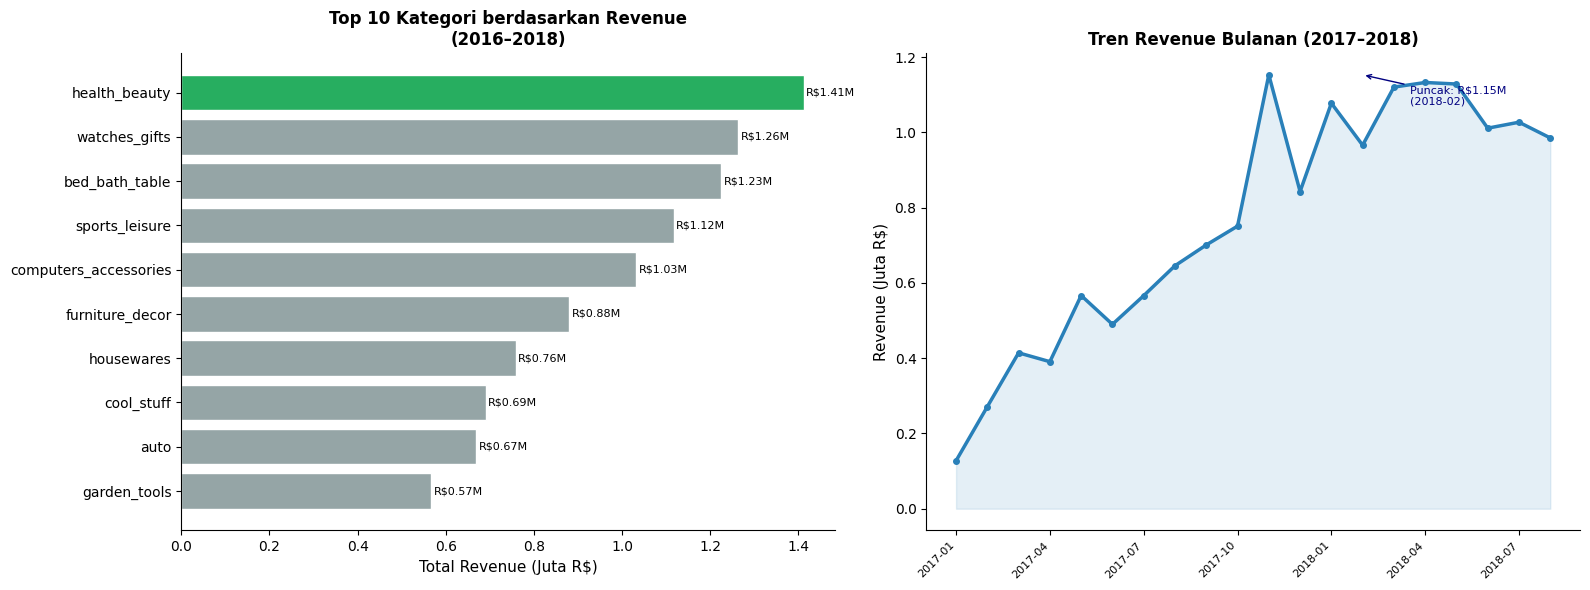

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart top 10 kategori
top10  = cat_revenue.head(10)
colors = ['#27ae60' if i == 0 else '#95a5a6' for i in range(10)]
bars   = axes[0].barh(top10.index[::-1], top10.values[::-1]/1e6,
                       color=colors[::-1], edgecolor='white')
axes[0].set_xlabel('Total Revenue (Juta R$)', fontsize=11)
axes[0].set_title('Top 10 Kategori berdasarkan Revenue\n(2016–2018)', fontsize=12, fontweight='bold')
for bar, val in zip(bars, top10.values[::-1]):
    axes[0].text(bar.get_width()+0.005, bar.get_y()+bar.get_height()/2,
                 f'R${val/1e6:.2f}M', va='center', fontsize=8)

# Line chart tren bulanan
axes[1].plot(range(len(monthly_rev)), monthly_rev['revenue']/1e6,
             color='#2980b9', linewidth=2.5, marker='o', markersize=4)
axes[1].fill_between(range(len(monthly_rev)), monthly_rev['revenue']/1e6,
                      alpha=0.12, color='#2980b9')
ticks = list(range(0, len(monthly_rev), 3))
axes[1].set_xticks(ticks)
axes[1].set_xticklabels([monthly_rev['month'].iloc[i] for i in ticks],
                          rotation=45, ha='right', fontsize=8)
axes[1].set_ylabel('Revenue (Juta R$)', fontsize=11)
axes[1].set_title('Tren Revenue Bulanan (2017–2018)', fontsize=12, fontweight='bold')
axes[1].yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))
peak_i = (monthly_rev['revenue']/1e6).idxmax()
axes[1].annotate(
    f'Puncak: R${monthly_rev["revenue"].max()/1e6:.2f}M\n({monthly_rev["month"].iloc[peak_i]})',
    xy=(peak_i, monthly_rev['revenue'].max()/1e6),
    xytext=(peak_i+1.5, monthly_rev['revenue'].max()/1e6 - 0.08),
    arrowprops=dict(arrowstyle='->', color='navy'), fontsize=8, color='navy'
)
plt.tight_layout()
plt.show()

### Pertanyaan 2: Apakah durasi pengiriman berpengaruh terhadap skor review pelanggan?

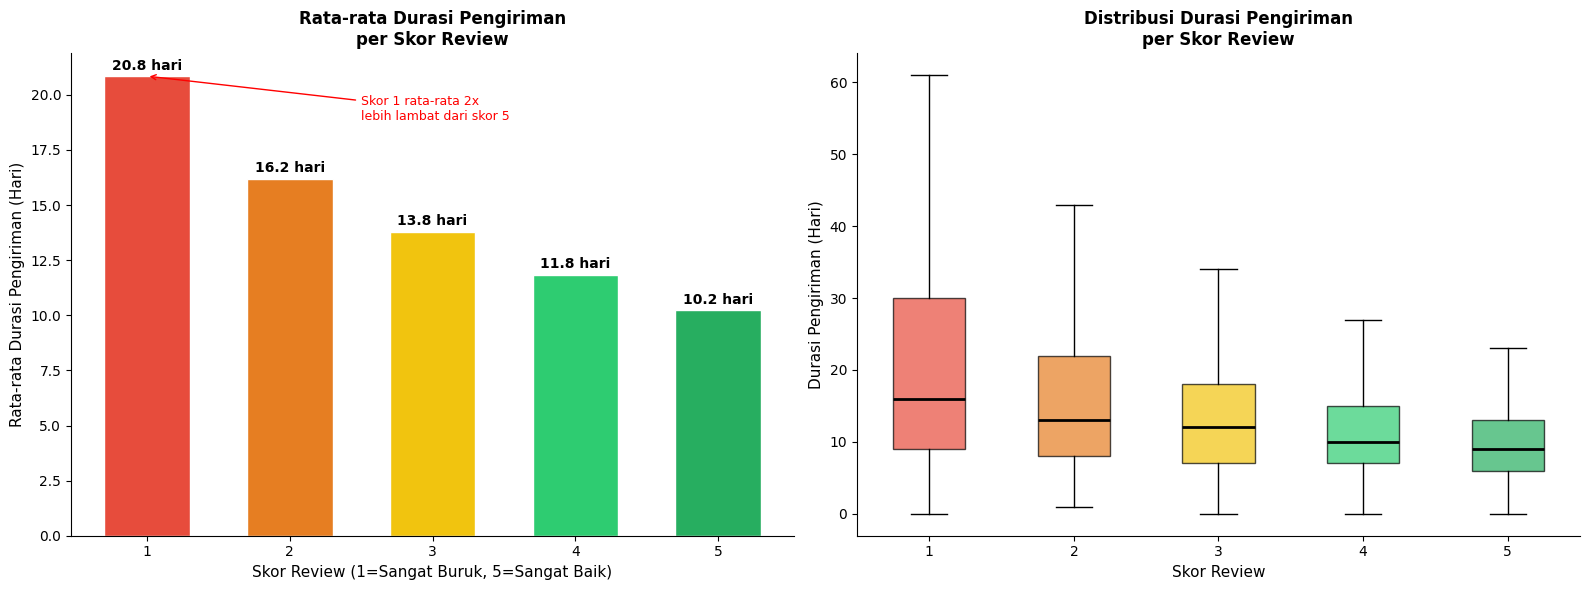

In [38]:
palette = ['#e74c3c','#e67e22','#f1c40f','#2ecc71','#27ae60']
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart rata-rata delivery days
avg_days = delivery_review_df.groupby('review_score')['delivery_days'].mean()
bars = axes[0].bar(avg_days.index, avg_days.values,
                   color=palette, edgecolor='white', width=0.6)
axes[0].set_xlabel('Skor Review (1=Sangat Buruk, 5=Sangat Baik)', fontsize=11)
axes[0].set_ylabel('Rata-rata Durasi Pengiriman (Hari)', fontsize=11)
axes[0].set_title('Rata-rata Durasi Pengiriman\nper Skor Review', fontsize=12, fontweight='bold')
axes[0].set_xticks([1,2,3,4,5])
for bar, val in zip(bars, avg_days.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 f'{val:.1f} hari', ha='center', fontsize=10, fontweight='bold')
axes[0].annotate('Skor 1 rata-rata 2x\nlebih lambat dari skor 5',
                  xy=(1, avg_days[1]), xytext=(2.5, avg_days[1]-2),
                  arrowprops=dict(arrowstyle='->', color='red'), fontsize=9, color='red')

# Box plot distribusi
groups = [delivery_review_df[delivery_review_df['review_score']==s]['delivery_days'].dropna()
          for s in [1,2,3,4,5]]
bp = axes[1].boxplot(groups, labels=[1,2,3,4,5], patch_artist=True,
                     medianprops=dict(color='black', linewidth=2), showfliers=False)
for patch, color in zip(bp['boxes'], palette):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_xlabel('Skor Review', fontsize=11)
axes[1].set_ylabel('Durasi Pengiriman (Hari)', fontsize=11)
axes[1].set_title('Distribusi Durasi Pengiriman\nper Skor Review', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

**Insight:**
- Visualisasi Q1: `health_beauty` unggul jauh dari kategori lain. Tren bulanan memperlihatkan lonjakan di November 2017, kemungkinan dipicu momen belanja akhir tahun.
- Visualisasi Q2: Hubungan negatif sangat jelas — semakin cepat pengiriman, semakin tinggi skor review yang diberikan pelanggan.

## Analisis Lanjutan (Opsional)

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Kategori `health_beauty` menghasilkan revenue tertinggi (>R$ 1,44 juta) sepanjang 2016–2018, diikuti `watches_gifts` dan `bed_bath_table`. Tren bulanan menunjukkan puncak di November 2017 (~R$ 1,18 juta), didorong momen belanja akhir tahun. Revenue stabil di kisaran R$ 800K–R$ 980K per bulan sepanjang 2018.

- **Conclusion pertanyaan 2:** Durasi pengiriman berpengaruh signifikan terhadap skor review pelanggan. Pesanan yang tiba dalam ≤10 hari cenderung mendapat skor 5, sedangkan pengiriman >20 hari konsisten mendapat skor 1. Kecepatan pengiriman adalah driver utama kepuasan pelanggan.

**Rekomendasi Action Item:**
- Optimalkan logistik untuk kategori `health_beauty`, `watches_gifts`, dan `bed_bath_table` terutama menjelang November–Desember.
- Tetapkan SLA maksimal 10 hari untuk seluruh pesanan agar kepuasan pelanggan terjaga.
- Buat sistem early warning jika estimasi pengiriman melebihi 12 hari agar tim operasional dapat mengambil tindakan proaktif sebelum pelanggan kecewa.

- **Conclusion pertanyaan 1:** xxx
- **Conclusion pertanyaan 2:** xxx
- ...

**Rekomendasi Action Item:**
- xxx
- xxx